## Perceptron Multi-couches

In [6]:
# Importation des librairies necessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm import tqdm
from sklearn.datasets import load_digits
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import validation_curve
from sklearn.metrics import confusion_matrix, classification_report

In [7]:
# Chargement des donnees
digits = load_digits()
print(digits['DESCR'])

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

### Partitionnement des données
Le dataset qui sera analysé dans cette section se rapporte à 1797 images de chiffres manuscrits, chacune de taille 8x8 pixels. Les images sont divisées en 10 classes : 0, 1, 2, 3, 4, 5, 6, 7, 8, 9. Chaque image est représentée par un tableau de 64 valeurs, chacune représentant l’intensité d’un pixel. Les valeurs des pixels sont comprises entre 0 et 16. 

<class 'pandas.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_4  1797 non

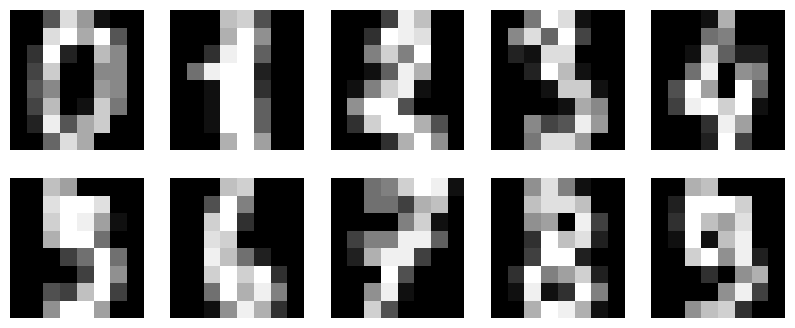

In [9]:
# Preparation du dataset
features = pd.DataFrame(data = digits['data'], columns = digits['feature_names'])
target = pd.DataFrame(data = digits['target'], columns=['digits'])

digits_data = pd.concat([features, target], axis = 1)
digits_data.info()

# Creation de la figure d'image
fig, axes = plt.subplots(nrows = 2, ncols = 5, figsize = (10, 4))
for i, ax in enumerate(axes.flatten()):
    sns.heatmap(data = digits.images[i], ax = ax, cmap = 'gray', cbar = False)
    ax.axis('off')

Le dataset étant prêt pour l’analyse, il peut être divisé en base d’apprentissage et base de test. Comme évoqué précédemment, le partitionnement des données permet d’éviter que le modèle tombe dans le piège du sur-apprentissage. Nous effectuerons la division aléatoire des données, en conservant 10% des enregistrements pour l’évaluation finale du modèle entraîıné.

In [13]:
# Partitionnement des donnees
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.1)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1617, 64) (180, 64) (1617, 1) (180, 1)


### Enraînement du modèle
Le modèle en réseau de neurones sera entraîné de sorte à sélectionner soigneusement les valeurs
des hyper-paramètres clés. La technique de la validation croisée sera utilisée à cet effet. 

La fonction GridSearchCV() du package scikit-learn nous permettra de définir des valeurs raisonnables des hyper-paramètres, puis de rechercher de manière exhaustive les valeurs optimales de ceux-ci. D’amples détails au sujet des hyper-paramètres à régler dans le cadre d’un réseau de neurones peuvent être trouvés dans la documentation relative à la fonction MLPClassifier(), laquelle permet d’implémenter un perceptron multi-couches .

In [18]:
# Entrainement du modele
warnings.filterwarnings('ignore')
hyper_param = {# profondeur du reseau
    'hidden_layer_sizes': [(10,), (10, 10,), (10, 10, 10)],
# fonction d'activation
'activation': ['logistic', 'tanh', 'relu'],
# type de taux d'apprentissage
'learning_rate': ['invscaling', 'adaptive'], 
# algorithme d'optimisation
'solver': ['lbfgs', 'sgd'],
# parametre de regularisation
'alpha': [.4, .5, .6]}
Grid_NN = GridSearchCV(MLPClassifier(random_state = 0), param_grid = hyper_param, cv = 10)

# Obtention du nombre total d'iterations pour la grille de recherche
len_layers = len(hyper_param['hidden_layer_sizes'])
len_act = len(hyper_param['activation'])
len_learn_rate = len(hyper_param['learning_rate'])
len_solver = len(hyper_param['solver'])
len_alpha = len(hyper_param['alpha'])
total_iter = len_layers* len_act * len_learn_rate * len_solver * len_alpha

# Affichage de la barre de progression
with tqdm(total=total_iter, desc = 'Grid Search Progress') as pbar:
    for param in Grid_NN.param_grid:
        Grid_NN.fit(X_train, y_train)
        pbar.update(1)

Grid Search Progress:   5%|███▍                                                                      | 5/108 [27:04<9:17:38, 324.84s/it]


Le code ci-dessus permet d’entrainer le modèle en optimisant les hyper-paramètres renseignés. Étant donné le nombre de valeurs à tester par hyper-paramètre, le temps requis pour l’exécution de ce code peut s’avérer être très long. Pour estimer ce temps, nous avons programmé, au moyen de la librairie tqdm, une barre de progression qui permet de suivre l’exécution du code à travers les itérations qui se succèdent. 
Pour ce cas précis, le nombre maximum d’itérations est estimé à H = 108 et la vitesse d’exécution du code à 1001.12 secondes par itérations, ce qui chiffre la durée requise pour l’exécution du code jusqu’à convergence de l’algorithme d’optimisation à 83 minutes et 25.6 secondes! 
Ce temps de traitement peut encore explosé si l’on rajoute d’autres couches supplémentaires dans le réseau. 
Vous l’avez compris, cela constitue l’une des principales limites de la librairie scikit-learn. 
C’est pour cette raison que nous proposons une prise en main de la librairie TensorFlow dans la section 5

In [ ]:
# Valeurs optimales des hyper-parametres
print(Grid_NN.best_parames_)

# Performance du modele dans l'apprentissage
NN_model = Grid_NN.best_estimator_
NN_model.score(X_train, y_train)

Après entraîınement du modèle, les résultats indiquent une performance de 95% sur la base d’apprentissage. 
Dans la Figure suivante, nous représentons dans le panel (a) l’évolution de l’accuracy du modèle durant la phase d’entraînement en fonction d’un hyper-paramètre clé, à savoir le taux d’apprentissage. 
Dans le panel (b) de cette même Figure, nous représentons l’évolution de la courbe d’apprentissage du modèle selon les itérations de l’algorithme d’optimisation. 
On constate que le modèle a été bien entraîné (car la courbe descend), ce qui justifie le score d’accuracy élevé obtenu pour l’apprentissage.

NameError: name 'NN_model' is not defined

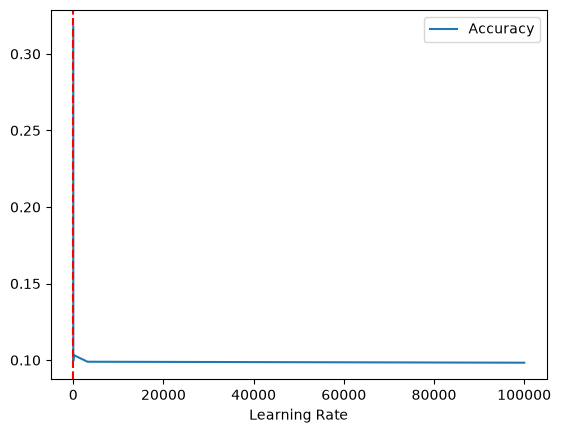

In [21]:
# Tuning process (reglage des hyper-parametres)
learning_rate = np.logspace(-1, 5,5)
score_train, score_cv = validation_curve(
    MLPClassifier(random_state=0), 
    X_train, y_train, cv = 10, 
    param_range=learning_rate, 
    param_name='learning_rate_init')

score_cv = pd.DataFrame(score_cv.mean(axis=1), columns=['Accuracy'])
score_cv.set_index(learning_rate, inplace = True)
score_cv.index.names = ['Learning Rate']
sns.lineplot(data=score_cv).axvline(score_cv['Accuracy'].idxmax(), color = 'red', linestyle = 'dashed');

# Courbe d'apprentissage
sns.lineplot(x = range(1, len(NN_model.loss_cure_) + 1), y = NN_model.loss_curve_)
plt.xlabel('Iterations')
plt.ylabel('Cout')

### Evaluation du modele

In [ ]:
# Rapport de classification et Matrice de confusion
y_predict_NN = NN_model.predict(X_test)
print(classification_report(y_test, y_predict_NN))
conf_matrix_NN = pd.DataFrame(confuion_matrix(y_test, y_predict_NN))
conf_matrix_NN

# Performance du modele au test
NN_model.score(X_test, y_test)